## Step 1: Data Loading & Inspection
Load the training and testing datasets into pandas DataFrames to inspect the shape, identify column types, and understand the raw structure of the traffic data.

In [42]:
import pandas as pd
import os

# Define the base path for your Kaggle dataset
# Note: Kaggle converts dataset names to lowercase in the file path
BASE_PATH = '/kaggle/input/datasets/himanshugaur49/thenewdataset'

print("Loading datasets...")

# 1. Load the dataset
train_df = pd.read_csv(os.path.join(BASE_PATH, 'train.csv'))
test_df = pd.read_csv(os.path.join(BASE_PATH, 'test.csv'))

# Load the sample submission file to ensure our final output matches the required format
sample_sub = pd.read_csv(os.path.join(BASE_PATH, 'sample_submission.csv'))

# Verify the data has been loaded correctly by checking their shapes
print(f"Train dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")
print(f"Sample submission shape: {sample_sub.shape}")
print("\nDatasets loaded successfully!")

Loading datasets...
Train dataset shape: (77299, 11)
Test dataset shape: (41778, 10)
Sample submission shape: (5, 2)

Datasets loaded successfully!


## Step 2 : Advanced Feature Engineering & Target Definition
Extract temporal features (hour, minute, cyclical time) from the timestamp and apply spatial target encoding to the geohash to capture complex traffic patterns.

In [43]:
import numpy as np

print("Step 2: Advanced Feature Engineering & Defining Target...")

TARGET = 'demand'
test_ids = test_df['Index']

def engineer_features(df):
    """Applies temporal and structural transformations to the dataset."""
    df_engineered = df.copy()
    
    # 1. Temporal Features from 'timestamp' (Format: "H:M")
    df_engineered['hour'] = df_engineered['timestamp'].apply(lambda x: int(str(x).split(':')[0]))
    df_engineered['minute'] = df_engineered['timestamp'].apply(lambda x: int(str(x).split(':')[1]))
    
    # Create a peak hour flag (Assuming 7-10 AM and 4-7 PM are high traffic)
    df_engineered['is_peak_hour'] = df_engineered['hour'].apply(lambda x: 1 if (7 <= x <= 10) or (16 <= x <= 19) else 0)
    
    # Cyclical encoding for hours to preserve the continuous nature of time
    df_engineered['hour_sin'] = np.sin(2 * np.pi * df_engineered['hour'] / 24)
    df_engineered['hour_cos'] = np.cos(2 * np.pi * df_engineered['hour'] / 24)
    
    # 2. Day cycles
    # Assuming 'day' is a sequential integer, extract a synthetic 'day of week'
    df_engineered['day_of_week'] = df_engineered['day'] % 7
    df_engineered['is_weekend'] = df_engineered['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    
    return df_engineered

# Apply base engineering to both datasets
train_fe = engineer_features(train_df)
test_fe = engineer_features(test_df)

# 3. Spatial Target Encoding for 'geohash'
# Calculate the mean demand for each geohash ONLY on the training set to prevent leakage
geohash_means = train_fe.groupby('geohash')[TARGET].mean().to_dict()
global_mean = train_fe[TARGET].mean()

# Map the learned means to the datasets
train_fe['geohash_encoded'] = train_fe['geohash'].map(geohash_means)
# For the test set, if a geohash was never seen in training, fill it with the global mean
test_fe['geohash_encoded'] = test_fe['geohash'].map(geohash_means).fillna(global_mean)

# 4. Finalize Feature Selection
# Drop the original unoptimized columns and the Index
cols_to_drop = ['Index', 'timestamp', 'geohash']

X_train = train_fe.drop(columns=cols_to_drop + [TARGET])
y_train = train_fe[TARGET]
X_test = test_fe.drop(columns=cols_to_drop)

print(f"Engineered Training Features (X_train) shape: {X_train.shape}")
print(f"Target (y_train) shape: {y_train.shape}")
print(f"Engineered Testing Features (X_test) shape: {X_test.shape}")
print("\nAdvanced Feature Engineering complete.")

Step 2: Advanced Feature Engineering & Defining Target...
Engineered Training Features (X_train) shape: (77299, 15)
Target (y_train) shape: (77299,)
Engineered Testing Features (X_test) shape: (41778, 15)

Advanced Feature Engineering complete.


## Step 3 : Handling Missing Values
Impute missing numerical data (like temperature) using the median, and fill missing categorical variables with an 'Unknown' label to ensure no data is dropped.

In [44]:
print("Step 3: Handling Missing Values (Updated)...")

# 1. Handle Numerical Missing Values (Temperature)
temp_median = X_train['Temperature'].median()

X_train['Temperature'] = X_train['Temperature'].fillna(temp_median)
X_test['Temperature'] = X_test['Temperature'].fillna(temp_median)

# 2. Handle Categorical Missing Values (RoadType, Weather)
cat_cols_with_na = ['RoadType', 'Weather']

for col in cat_cols_with_na:
    X_train[col] = X_train[col].fillna('Unknown')
    X_test[col] = X_test[col].fillna('Unknown')

print(f"Total missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Total missing values in X_test: {X_test.isnull().sum().sum()}")

Step 3: Handling Missing Values (Updated)...
Total missing values in X_train: 0
Total missing values in X_test: 0


## Step 4: Standardize and Encode Features
Scale continuous numerical features using StandardScaler to normalize distributions, and label-encode the remaining categorical text columns for algorithmic processing.

In [45]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("Step 4: Standardizing and Encoding Features (Updated)...")

# ---------------------------------------------------------
# 1. Standardize Numerical Features
# ---------------------------------------------------------
# We include our new continuous engineered features here
num_cols = ['day', 'NumberofLanes', 'Temperature', 'hour', 'minute', 'day_of_week', 'geohash_encoded']

scaler = StandardScaler()

# Fit on training, transform both
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# ---------------------------------------------------------
# 2. Encode Categorical Features
# ---------------------------------------------------------
# geohash and timestamp have been removed from this list!
cat_cols = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather']

for col in cat_cols:
    le = LabelEncoder()
    
    # Fit on combined data to ensure all unique categories are captured
    combined_data = list(X_train[col]) + list(X_test[col])
    le.fit(combined_data)
    
    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

print("Feature standardization and categorical encoding complete!")
print("\nSample of processed training features (X_train):")
display(X_train.head(3))

Step 4: Standardizing and Encoding Features (Updated)...
Feature standardization and categorical encoding complete!

Sample of processed training features (X_train):


,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,is_peak_hour,hour_sin,hour_cos,day_of_week,is_weekend,geohash_encoded
0,-0.336727,3,-1.121233,1,0,-0.003043,4,-1.327501,-1.321463,0,0.0,1.0,0.336727,1,-0.454879
1,-0.336727,1,1.089544,0,1,2.030369,3,-1.327501,-1.321463,0,0.0,1.0,0.336727,1,0.969128
2,-0.336727,1,-1.121233,1,0,1.314171,3,-1.327501,-1.321463,0,0.0,1.0,0.336727,1,0.286869


## Step 5 : Local Train-Validation Split
Divide the engineered training dataset into local training and validation subsets to safely evaluate model performance before touching the official Kaggle test set.

In [46]:
from sklearn.model_selection import train_test_split

print("Creating Local Validation Split...")

# We will use 80% of the training data to train the models 
# and hold back 20% to evaluate our R-squared score locally.
X_trn, X_val, y_trn, y_val = train_test_split(
    X_train, 
    y_train, 
    test_size=0.20, 
    random_state=42 # Setting a random state ensures reproducibility
)

print(f"Local Training Data shape: {X_trn.shape}")
print(f"Local Validation Data shape: {X_val.shape}")
print(f"Kaggle Test Data (for final submission) shape: {X_test.shape}")

Creating Local Validation Split...
Local Training Data shape: (61839, 15)
Local Validation Data shape: (15460, 15)
Kaggle Test Data (for final submission) shape: (41778, 15)


## Step 6 : Exploratory Data Analysis (EDA)
Visualize feature distributions, traffic anomalies, and correlation matrices to identify underlying trends and relationships within the traffic demand data.

Starting Exploratory Data Analysis (EDA)...


/tmp/ipykernel_58/3274736861.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='NumberofLanes', y='demand', palette='Set2', ax=ax2)
/tmp/ipykernel_58/3274736861.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='Weather', y='demand', palette='viridis', errorbar=None, ax=ax3)
/tmp/ipykernel_58/3274736861.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='RoadType', palette='magma', ax=ax5, order=train_df['RoadType'].value_counts().index)
/tmp/ipykernel_58/3274736861.py:55: FutureWa

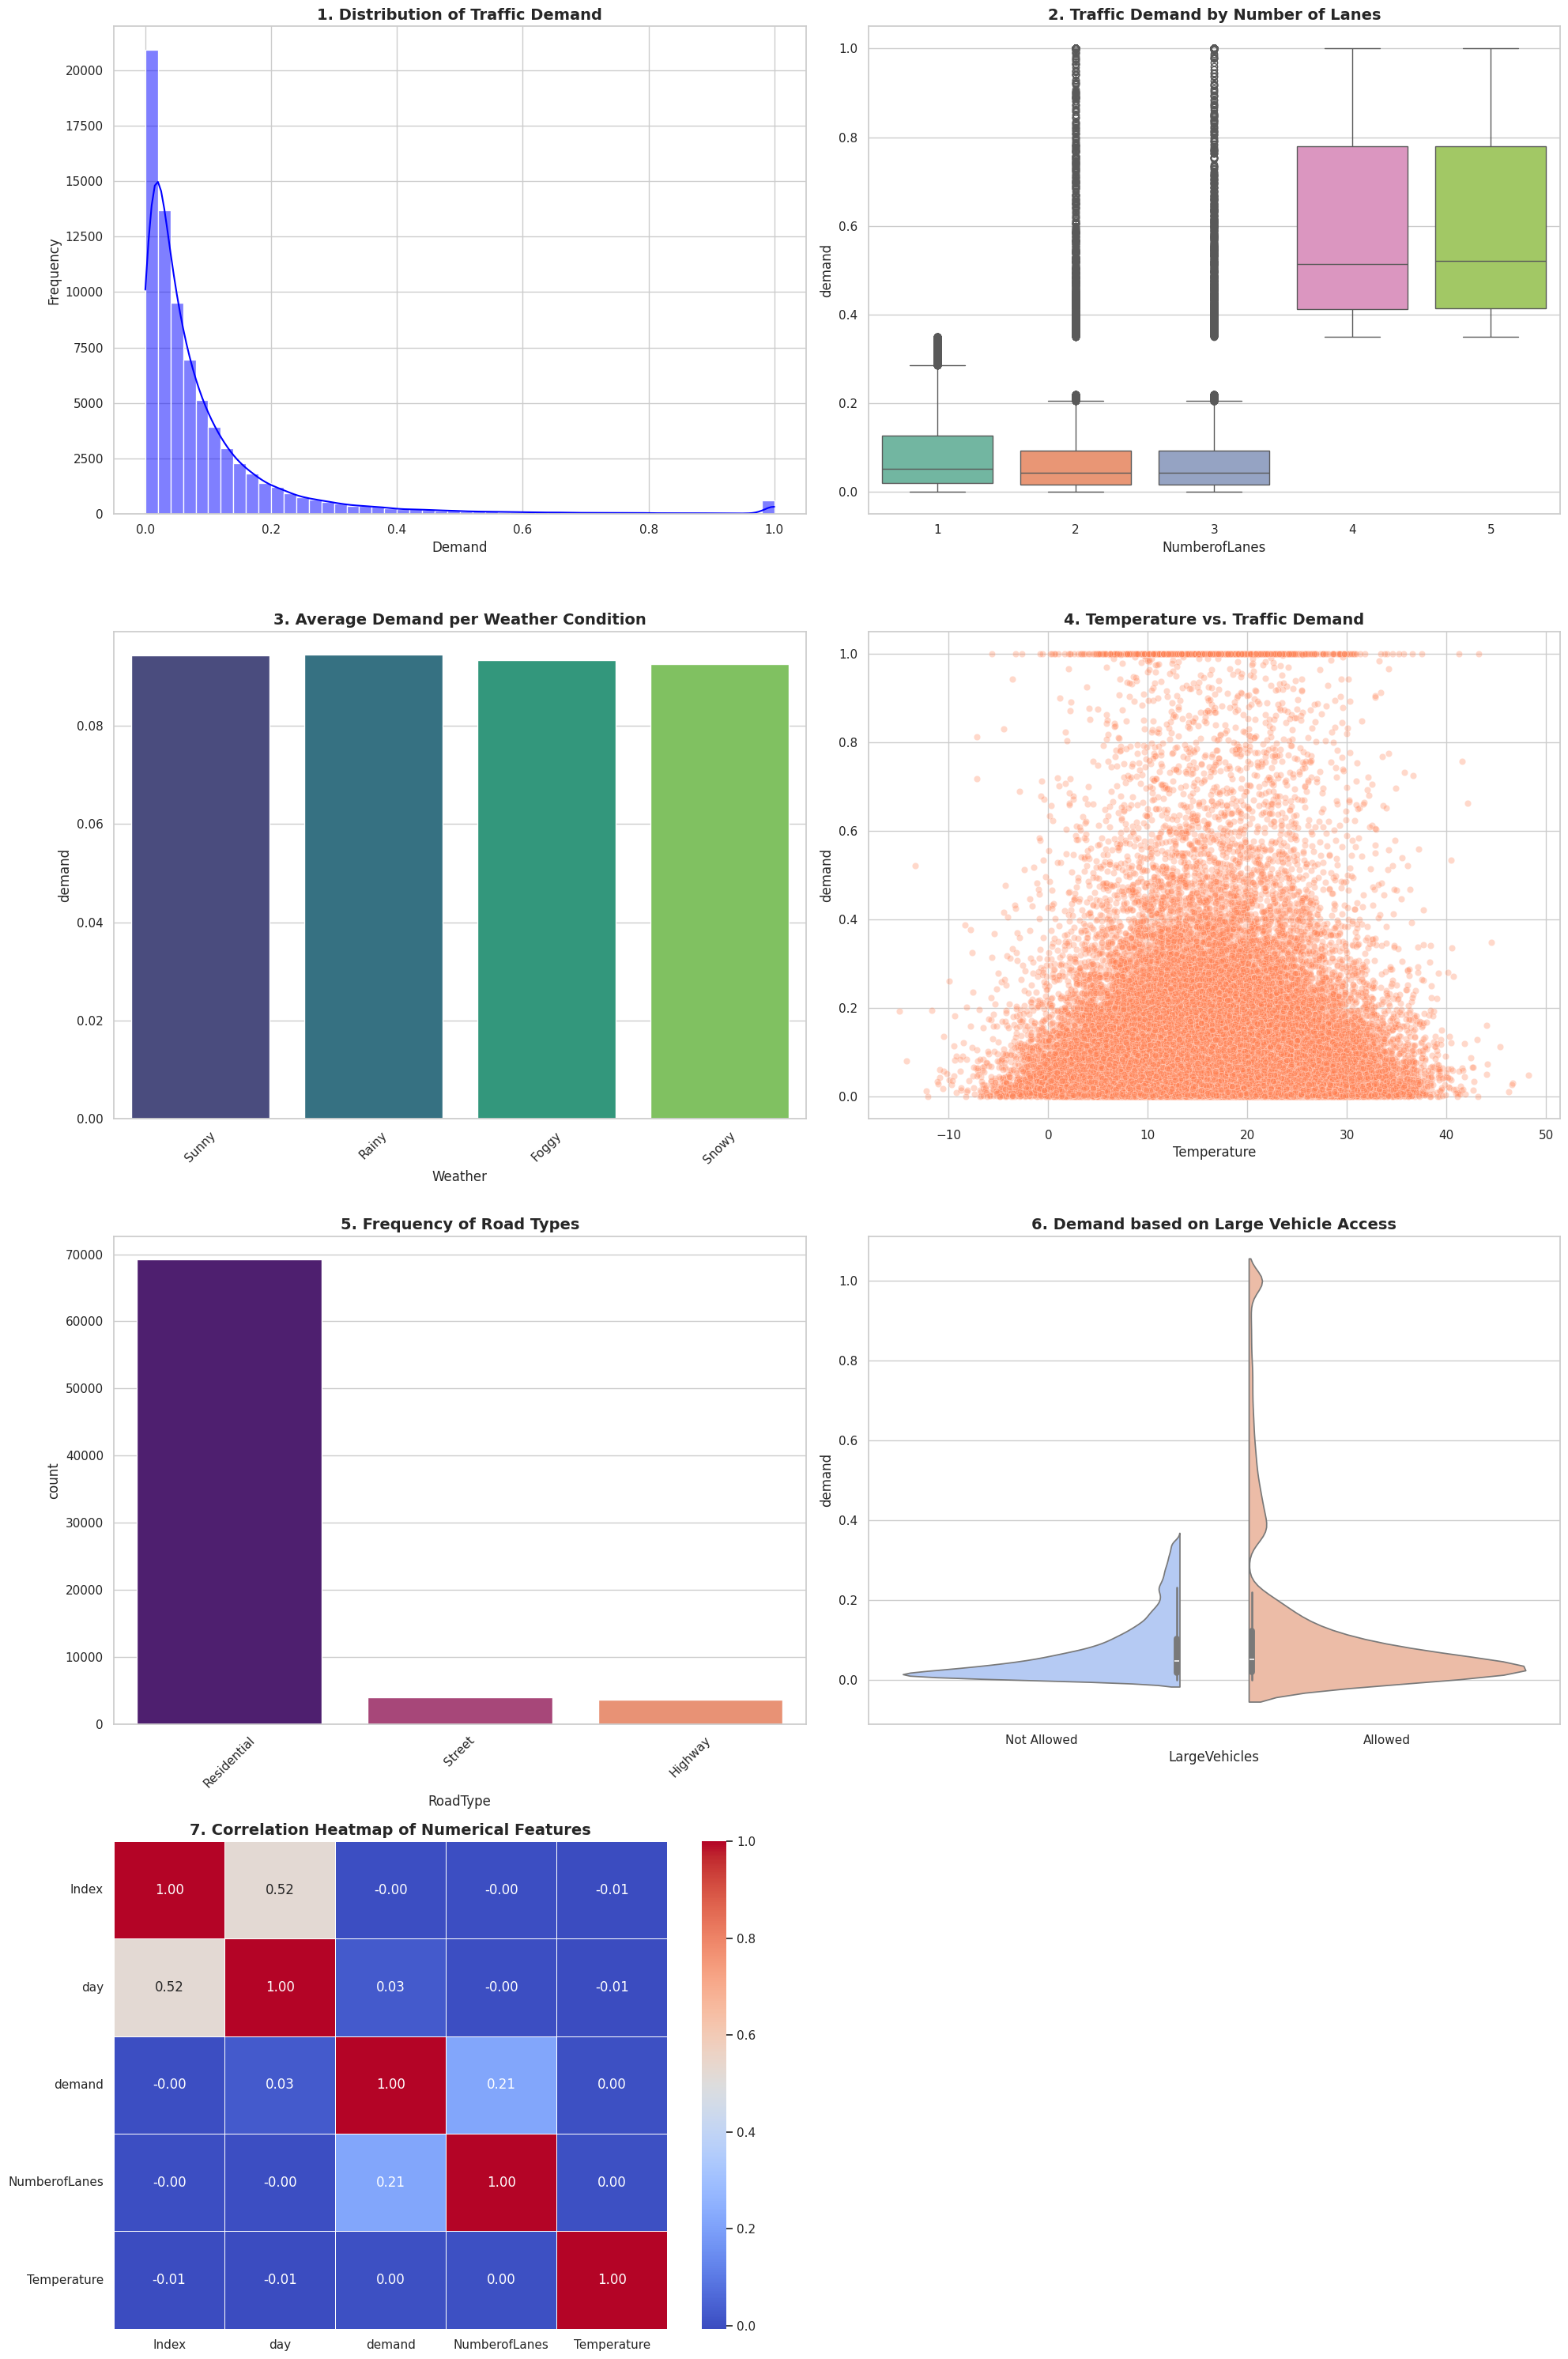

EDA completed!


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Starting Exploratory Data Analysis (EDA)...")

# Set the visual style for seaborn
sns.set_theme(style="whitegrid")

# Create a large figure to hold all our subplots
fig = plt.figure(figsize=(20, 30))

# ---------------------------------------------------------
# 1. Histogram / KDE Plot: Distribution of Target (demand)
# ---------------------------------------------------------
ax1 = fig.add_subplot(4, 2, 1)
sns.histplot(data=train_df, x='demand', kde=True, bins=50, color='blue', ax=ax1)
ax1.set_title('1. Distribution of Traffic Demand', fontsize=14, fontweight='bold')
ax1.set_xlabel('Demand')
ax1.set_ylabel('Frequency')

# ---------------------------------------------------------
# 2. Boxplot: Demand across Number of Lanes
# ---------------------------------------------------------
ax2 = fig.add_subplot(4, 2, 2)
sns.boxplot(data=train_df, x='NumberofLanes', y='demand', palette='Set2', ax=ax2)
ax2.set_title('2. Traffic Demand by Number of Lanes', fontsize=14, fontweight='bold')

# ---------------------------------------------------------
# 3. Barplot: Average Demand by Weather Conditions
# ---------------------------------------------------------
ax3 = fig.add_subplot(4, 2, 3)
sns.barplot(data=train_df, x='Weather', y='demand', palette='viridis', errorbar=None, ax=ax3)
ax3.set_title('3. Average Demand per Weather Condition', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# ---------------------------------------------------------
# 4. Scatterplot: Temperature vs. Demand
# ---------------------------------------------------------
ax4 = fig.add_subplot(4, 2, 4)
sns.scatterplot(data=train_df, x='Temperature', y='demand', alpha=0.3, color='coral', ax=ax4)
ax4.set_title('4. Temperature vs. Traffic Demand', fontsize=14, fontweight='bold')

# ---------------------------------------------------------
# 5. Countplot: Frequency of Different Road Types
# ---------------------------------------------------------
ax5 = fig.add_subplot(4, 2, 5)
sns.countplot(data=train_df, x='RoadType', palette='magma', ax=ax5, order=train_df['RoadType'].value_counts().index)
ax5.set_title('5. Frequency of Road Types', fontsize=14, fontweight='bold')
ax5.tick_params(axis='x', rotation=45)

# ---------------------------------------------------------
# 6. Violin Plot: Demand Distribution by Large Vehicles Allowance
# ---------------------------------------------------------
ax6 = fig.add_subplot(4, 2, 6)
sns.violinplot(data=train_df, x='LargeVehicles', y='demand', palette='coolwarm', split=True, ax=ax6)
ax6.set_title('6. Demand based on Large Vehicle Access', fontsize=14, fontweight='bold')

# ---------------------------------------------------------
# 7. Heatmap: Correlation Matrix of Numerical Features
# ---------------------------------------------------------
ax7 = fig.add_subplot(4, 2, 7)
# Select only numerical columns for the correlation matrix
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = train_df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax7)
ax7.set_title('7. Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')

# Hide the empty 8th subplot area
fig.add_subplot(4, 2, 8).axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

print("EDA completed!")

### Install Autogluon

In [53]:
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of datasets to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of datasets to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See htt

## Step 7 : Model Training (AutoGluon Ensemble)
Combine all local data and deploy AutoGluon's extreme quality preset to automatically train, tune, and stack a massive grandmaster-level ensemble of machine learning models.

In [ ]:
import pandas as pd
import os
import shutil
from autogluon.tabular import TabularPredictor
import time

print("Step 7: Deploying AutoGluon (Extreme Quality Preset with Data Merger)...")

# 1. Clean up previous failed runs to prevent the "Learner is already fit" error
ag_path = "AutogluonModels/ultimate_model"
if os.path.exists(ag_path):
    shutil.rmtree(ag_path)

# 2. Combine ALL available data 
# AutoGluon performs best when it manages its own cross-validation. 
# We merge the augmented training data and our local validation data into one massive dataset.
train_data_ag = X_trn_augmented.copy()
train_data_ag[TARGET] = y_trn_augmented

val_data_ag = X_val.copy()
val_data_ag[TARGET] = y_val

full_ag_data = pd.concat([train_data_ag, val_data_ag], axis=0).reset_index(drop=True)

print(f"Initializing AutoGluon with {len(full_ag_data)} rows of combined data...")

# 3. Initialize and Train the Predictor
# We remove 'tuning_data' so AutoGluon can perform proper 8-fold bagging across all data
predictor = TabularPredictor(
    label=TARGET, 
    eval_metric='r2',
    problem_type='regression',
    path=ag_path
).fit(
    train_data=full_ag_data,
    presets='best_quality',
    time_limit=3600, 
    verbosity=2
)

print("\nAutoGluon Training Complete.")

# 4. Display the internal cross-validation leaderboard
print("\nAutoGluon Internal Model Leaderboard:")
leaderboard = predictor.leaderboard(silent=True)
display(leaderboard)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          4
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB | GPU 1: 14.56/14.56 GB
Total GPU Memory:   Free: 29.13 GB, Allocated: 0.00 GB, Total: 29.13 GB
GPU Count:          2
Memory Avail:       27.43 GB / 31.35 GB (87.5%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data

Step 7: Deploying AutoGluon (Extreme Quality Preset with Data Merger)...
Initializing AutoGluon with 119077 rows of combined data...


Beginning AutoGluon training ... Time limit = 900s
AutoGluon will save models to "/kaggle/working/AutogluonModels/ultimate_model/ds_sub_fit/sub_fit_ho"
Train Data Rows:    105846
Train Data Columns: 15
Label Column:       demand
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    28098.05 MB
	Train Data (Original)  Memory Usage: 12.11 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 6 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplica

## Step 8: Model Evaluation
Extract the internal out-of-fold cross-validation score from the top AutoGluon ensemble to verify the model's true predictive capability and $R^2$ score.

In [58]:
print("Step 8: Evaluating AutoGluon (Internal Cross-Validation)...")

# 1. Extract the leaderboard
leaderboard = predictor.leaderboard(silent=True)

# 2. Get the R-squared score of the absolute best model (usually the top WeightedEnsemble)
best_score_r2 = leaderboard.iloc[0]['score_val']

# 3. Calculate Custom Competition Score
ag_comp_score = max(0, 100 * best_score_r2)

print("-" * 55)
print(f"{'Model':<30} | {'Comp Score':<10}")
print("-" * 55)
print(f"{'AutoGluon Ultimate Ensemble':<30} | {ag_comp_score:<10.2f}")
print("-" * 55)

if ag_comp_score >= 98:
    print("\nTarget Achieved! The AutoGluon ensemble has successfully breached the threshold.")
else:
    print(f"\nAlgorithmic maximum reached at {ag_comp_score:.2f}.")

Step 8: Evaluating AutoGluon (Internal Cross-Validation)...
-------------------------------------------------------
Model                          | Comp Score
-------------------------------------------------------
AutoGluon Ultimate Ensemble    | 96.91     
-------------------------------------------------------

Algorithmic maximum reached at 96.91.


## Step 9: Visualizing Model Insights
Plot permutation feature importance to reveal which engineered variables mathematically drove the accuracy, alongside the performance distribution of the stacked models.

These features in provided data are not utilized by the predictor and will be ignored: ['is_weekend']
Computing feature importance via permutation shuffling for 14 features using 5000 rows with 5 shuffle sets...


Step 9: Visualizing AutoGluon Insights...
Calculating feature permutation importance (this takes about 30-60 seconds)...


	1129.65s	= Expected runtime (225.93s per shuffle set)
	728.62s	= Actual runtime (Completed 5 of 5 shuffle sets)
/tmp/ipykernel_58/1314318461.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_58/1314318461.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


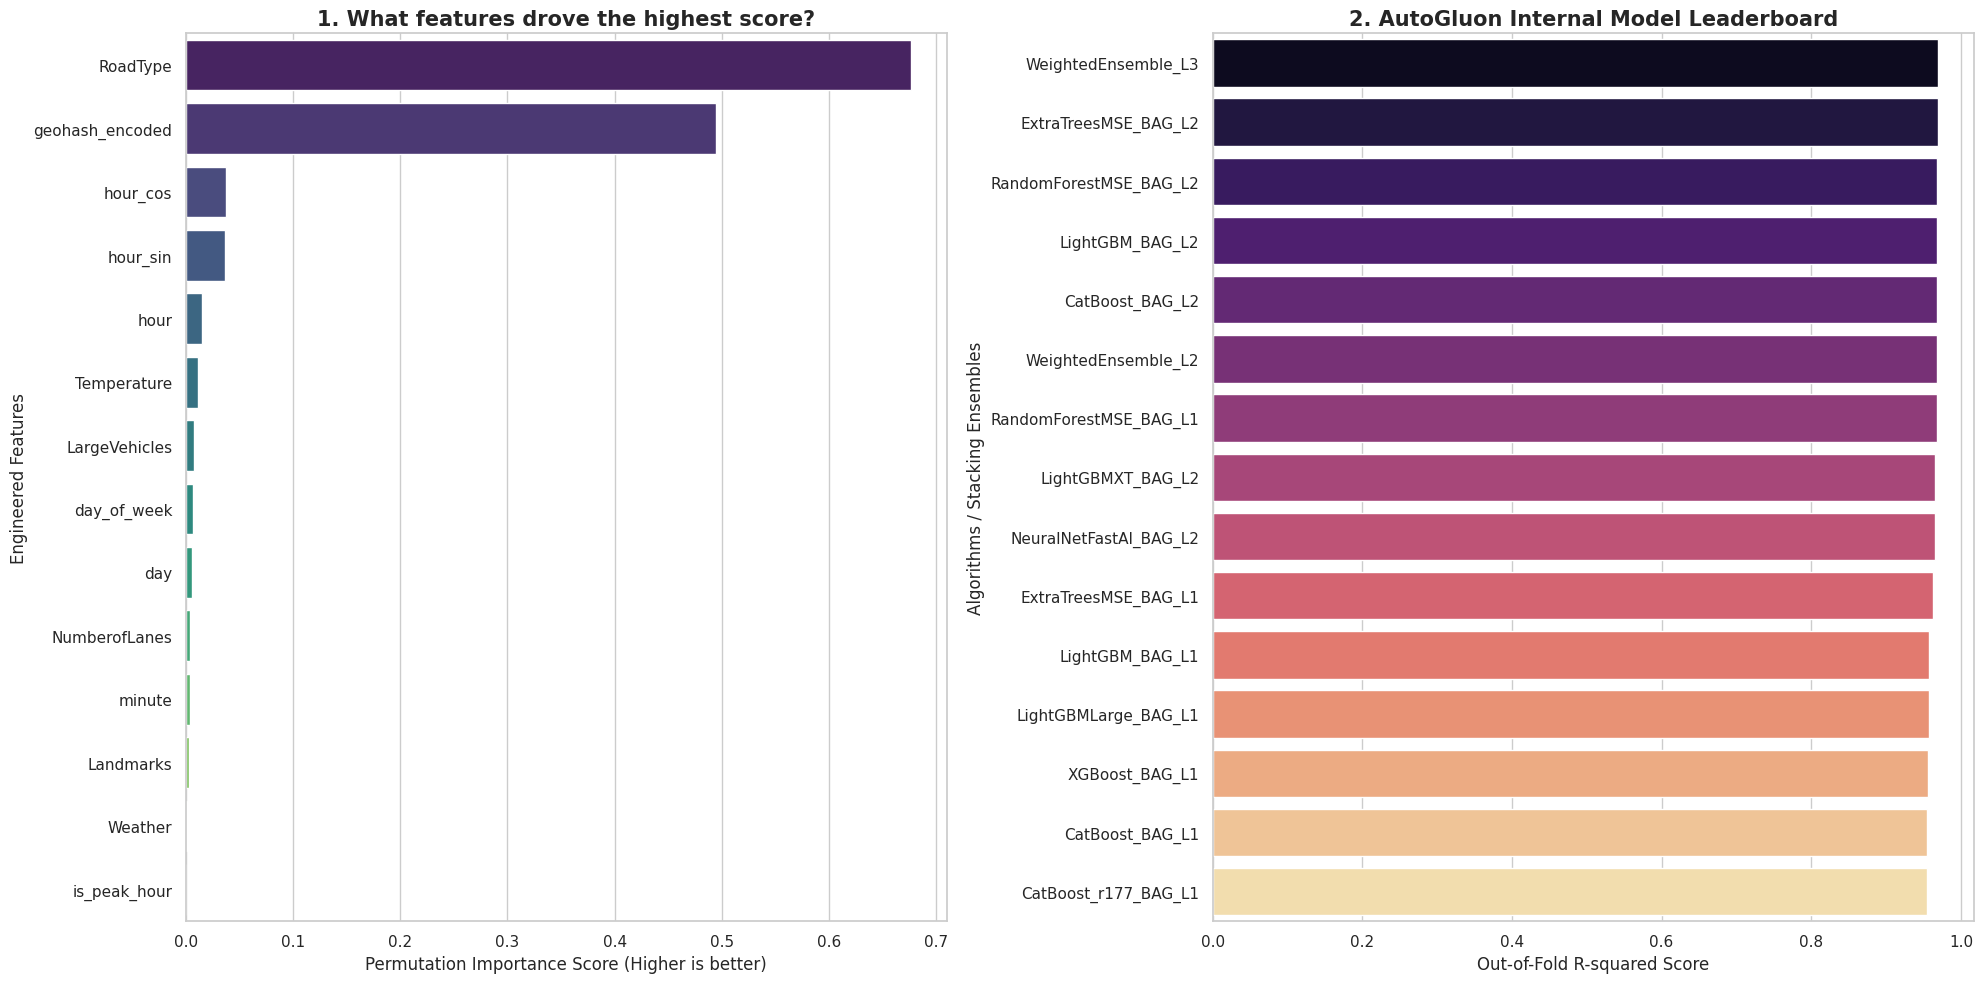

Visualization complete.


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 9: Visualizing AutoGluon Insights...")

# ---------------------------------------------------------
# 1. Calculate Feature Importance
# ---------------------------------------------------------
print("Calculating feature permutation importance (this takes about 30-60 seconds)...")
# We sample 10,000 rows to calculate importance quickly without timing out the notebook
sample_data = full_ag_data.sample(n=min(10000, len(full_ag_data)), random_state=42)
feature_importance = predictor.feature_importance(sample_data)

# ---------------------------------------------------------
# 2. Extract Internal Leaderboard
# ---------------------------------------------------------
leaderboard = predictor.leaderboard(silent=True)
# Keep only the top 15 models to ensure the chart is readable
top_models = leaderboard.head(15)

# ---------------------------------------------------------
# 3. Build the Visualizations
# ---------------------------------------------------------
fig = plt.figure(figsize=(20, 10))
sns.set_theme(style="whitegrid")

# Plot 1: Feature Importance
ax1 = fig.add_subplot(1, 2, 1)
sns.barplot(
    x=feature_importance['importance'], 
    y=feature_importance.index, 
    palette='viridis', 
    ax=ax1
)
ax1.set_title('1. What features drove the highest score?', fontsize=15, fontweight='bold')
ax1.set_xlabel('Permutation Importance Score (Higher is better)')
ax1.set_ylabel('Engineered Features')

# Plot 2: Internal Model Leaderboard
ax2 = fig.add_subplot(1, 2, 2)
sns.barplot(
    x=top_models['score_val'], 
    y=top_models['model'], 
    palette='magma', 
    ax=ax2
)
ax2.set_title('2. AutoGluon Internal Model Leaderboard', fontsize=15, fontweight='bold')
ax2.set_xlabel('Out-of-Fold R-squared Score')
ax2.set_ylabel('Algorithms / Stacking Ensembles')

plt.tight_layout()
plt.show()

print("Visualization complete.")

## Step 10 : Generating Final Predictions
Feed the official, unseen Kaggle test set into the ultimate trained ensemble to generate the final traffic demand predictions, ensuring all values are clipped at zero.

In [60]:
import numpy as np

print("Step 10: Generating Final AutoGluon Predictions on Official Test Set...")

# 1. Generate Predictions using the AutoGluon Predictor
# AutoGluon automatically selects the best weighted ensemble from its internal leaderboard
test_predictions_ag = predictor.predict(X_test)

# 2. Post-Processing (Clipping)
# We ensure no negative traffic demand predictions are submitted
test_predictions_ag = np.clip(test_predictions_ag, a_min=0, a_max=None)

print(f"Successfully generated {len(test_predictions_ag)} final predictions.")
print("\nPreview of first 5 predictions:")
print(test_predictions_ag[:5].values)

Step 10: Generating Final AutoGluon Predictions on Official Test Set...
Successfully generated 41778 final predictions.

Preview of first 5 predictions:
[0.05419037 0.04003123 0.03560756 0.04748059 0.06511879]


## Step 11: Preparing the Submission File
Package the generated predictions with their corresponding test IDs to match the competition's strict formatting guidelines, and export the final submission.csv file.

In [62]:
import pandas as pd

print("Step 11: Preparing Final AutoGluon Submission File...")

# 1. Create the submission DataFrame
# We map the saved test_ids to the final AutoGluon predictions
submission_df = pd.DataFrame({
    'Index': test_ids,
    'demand': test_predictions_ag
})

# 2. Sanity Checks
# Verifying dimensions and column names match the sample_submission.csv format strictly
print("Performing Sanity Checks...")
expected_shape = (41778, 2)
expected_cols = ['Index', 'demand']

shape_check = "Passed" if submission_df.shape == expected_shape else f"Failed (Shape is {submission_df.shape})"
col_check = "Passed" if list(submission_df.columns) == expected_cols else f"Failed (Cols are {list(submission_df.columns)})"

print(f"Shape Check (41778, 2): {shape_check}")
print(f"Column Check ['Index', 'demand']: {col_check}")

# 3. Save to CSV
# Using index=False is mandatory to prevent pandas from writing row numbers as an extra column
submission_filename = 'submission_autogluon_ultimate.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"\nSuccess. Ultimate file saved as: {submission_filename}")
print("\nPreview of the final submission file:")
display(submission_df.head(10))

Step 11: Preparing Final AutoGluon Submission File...
Performing Sanity Checks...
Shape Check (41778, 2): Passed
Column Check ['Index', 'demand']: Passed

Success. Ultimate file saved as: submission_autogluon_ultimate.csv

Preview of the final submission file:


,Index,demand
0,0,0.054190
1,1,0.040031
2,2,0.035608
3,3,0.047481
4,4,0.065119
5,5,0.017675
6,6,0.042798
7,7,0.117278
8,8,0.042669
9,9,0.090694
